# Spatial VQ-VAE Variant (DeMemte)

Variante basada en **Spatial ConvVAE**, reemplazando el bloque variacional continuo por **VQ-VAE espacial** con codebook EMA.

Objetivos:
- Usar `d_q = ||z_e - z_q||^2` como señal de familiaridad.
- Hacer compuerta por muestra (no por batch global) para estabilidad.
- Entrenar en **feature-space denoising**: `input=noisy_feats`, `target=clean_feats`.

## 1) Environment Setup and Imports

In [21]:
# Si falta algo, descomenta:
# !pip install torch torchvision matplotlib scikit-learn

import os
import copy
import json
import random
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Dict, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, Subset

import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import StratifiedKFold

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('cuda:', torch.cuda.is_available())

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
cuda: True


## 2) Project Configuration and Constants

In [22]:
@dataclass
class Config:
    data_dir: str = '../data'
    num_classes: int = 102
    batch_size: int = 64
    num_workers: int = 2

    # Entrenamiento base
    epochs_phase1: int = 5
    epochs_phase2: int = 8
    lr_vq: float = 3e-4
    lr_cls: float = 1e-3
    weight_decay: float = 1e-4

    # Ruido en feature-space (Option B)
    feature_noise_std: float = 0.35

    # VQ-VAE
    embedding_dim: int = 128
    num_embeddings: int = 512
    commitment_cost: float = 0.25
    ema_decay: float = 0.99
    eps: float = 1e-5

    # Gate por familiaridad
    init_tau: float = 0.0
    init_alpha: float = 1.5
    init_memory_scale: float = 1.0

    # Pérdidas
    denoise_weight: float = 1.0
    vq_weight: float = 1.0

    # Cross-validation / anti-overfit
    n_splits: int = 3
    cv_seed: int = 42
    early_stop_patience_p1: int = 2
    early_stop_patience_p2: int = 3
    early_stop_min_delta: float = 1e-4
    scheduler_factor: float = 0.5
    scheduler_patience: int = 1

    # Artefactos
    artifacts_root: str = './VQ/artifacts'
    experiment_name: str = 'spatial_vqvae_cv'

    # Debug
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    max_train_batches_debug: int = 20
    max_val_batches_debug: int = 10

cfg = Config()
print(json.dumps(asdict(cfg), indent=2))

{
  "data_dir": "../data",
  "num_classes": 102,
  "batch_size": 64,
  "num_workers": 2,
  "epochs_phase1": 5,
  "epochs_phase2": 8,
  "lr_vq": 0.0003,
  "lr_cls": 0.001,
  "weight_decay": 0.0001,
  "feature_noise_std": 0.35,
  "embedding_dim": 128,
  "num_embeddings": 512,
  "commitment_cost": 0.25,
  "ema_decay": 0.99,
  "eps": 1e-05,
  "init_tau": 0.0,
  "init_alpha": 1.5,
  "init_memory_scale": 1.0,
  "denoise_weight": 1.0,
  "vq_weight": 1.0,
  "n_splits": 3,
  "cv_seed": 42,
  "early_stop_patience_p1": 2,
  "early_stop_patience_p2": 3,
  "early_stop_min_delta": 0.0001,
  "scheduler_factor": 0.5,
  "scheduler_patience": 1,
  "artifacts_root": "./VQ/artifacts",
  "experiment_name": "spatial_vqvae_cv",
  "device": "cuda",
  "max_train_batches_debug": 20,
  "max_val_batches_debug": 10
}


## 3) Input Loading and Preprocessing

In [16]:
def _extract_labels(dataset):
    if hasattr(dataset, '_labels'):
        return np.array(dataset._labels)
    if hasattr(dataset, 'labels'):
        return np.array(dataset.labels)

    labels = []
    for i in range(len(dataset)):
        _, y = dataset[i]
        labels.append(int(y))
    return np.array(labels)


def build_datasets(config: Config):
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    transform_eval = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    trainset = torchvision.datasets.Flowers102(root=config.data_dir, split='train', download=False, transform=transform_train)
    valset = torchvision.datasets.Flowers102(root=config.data_dir, split='val', download=False, transform=transform_eval)
    testset = torchvision.datasets.Flowers102(root=config.data_dir, split='test', download=False, transform=transform_eval)

    cv_dataset = ConcatDataset([trainset, valset])
    cv_labels = np.concatenate([_extract_labels(trainset), _extract_labels(valset)], axis=0)

    testloader = DataLoader(testset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
    return cv_dataset, cv_labels, testset, testloader


cv_dataset, cv_labels, testset, testloader = build_datasets(cfg)
print('cv size:', len(cv_dataset), '| classes:', len(np.unique(cv_labels)))
xb, yb = next(iter(testloader))
print('test batch x:', tuple(xb.shape), 'batch y:', tuple(yb.shape))

cv size: 2040 | classes: 102


test batch x: (64, 3, 224, 224) batch y: (64,)


## 4) Core Function/Class Implementation

In [17]:
def make_spatial_backbone():
    """ResNet18 truncado para obtener feature map [B, 512, 7, 7]."""
    base = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    body = list(base.children())[:-2]
    return nn.Sequential(*body)


class VectorQuantizerEMA(nn.Module):
    """Vector Quantization con codebook EMA para evitar collapse."""
    def __init__(self, num_embeddings: int, embedding_dim: int, commitment_cost: float = 0.25,
                 decay: float = 0.99, eps: float = 1e-5):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.decay = decay
        self.eps = eps

        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

        self.register_buffer('ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer('ema_w', self.embedding.weight.data.clone())

    def forward(self, z_e: torch.Tensor):
        # z_e: [B, C, H, W], C=embedding_dim
        b, c, h, w = z_e.shape
        assert c == self.embedding_dim

        z_e_perm = z_e.permute(0, 2, 3, 1).contiguous()      # [B,H,W,C]
        flat = z_e_perm.view(-1, c)                           # [N,C]

        emb = self.embedding.weight                           # [K,C]
        distances = (
            flat.pow(2).sum(dim=1, keepdim=True)
            - 2 * flat @ emb.t()
            + emb.pow(2).sum(dim=1, keepdim=True).t()
        )

        encoding_indices = torch.argmin(distances, dim=1)     # [N]
        encodings = F.one_hot(encoding_indices, self.num_embeddings).type(flat.dtype)

        quantized_flat = encodings @ emb                       # [N,C]
        quantized = quantized_flat.view(b, h, w, c).permute(0, 3, 1, 2).contiguous()

        if self.training:
            n = encodings.sum(dim=0)
            dw = encodings.t() @ flat

            self.ema_cluster_size.mul_(self.decay).add_(n, alpha=1 - self.decay)
            self.ema_w.mul_(self.decay).add_(dw, alpha=1 - self.decay)

            total = self.ema_cluster_size.sum()
            cluster_size = (
                (self.ema_cluster_size + self.eps)
                / (total + self.num_embeddings * self.eps)
                * total
            )
            normalized_embed = self.ema_w / cluster_size.unsqueeze(1)
            self.embedding.weight.data.copy_(normalized_embed)

        commitment_loss = self.commitment_cost * F.mse_loss(z_e, quantized.detach())
        quantized_st = z_e + (quantized - z_e).detach()       # STE

        avg_probs = encodings.float().mean(dim=0)
        perplexity = torch.exp(-(avg_probs * torch.log(avg_probs + 1e-10)).sum())

        # señal directa de familiaridad: d_q = ||z_e - z_q||^2
        dq_map = ((z_e - quantized.detach()) ** 2).mean(dim=1, keepdim=True)

        code_map = encoding_indices.view(b, h, w)
        return quantized_st, commitment_loss, dq_map, perplexity, code_map


class SpatialVQVAE(nn.Module):
    """VQ-VAE espacial: entrada/salida [B,512,7,7]."""
    def __init__(self, in_channels=512, hidden_channels=256, embedding_dim=128,
                 num_embeddings=512, commitment_cost=0.25, decay=0.99, eps=1e-5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, embedding_dim, kernel_size=1),
        )

        self.vq = VectorQuantizerEMA(
            num_embeddings=num_embeddings,
            embedding_dim=embedding_dim,
            commitment_cost=commitment_cost,
            decay=decay,
            eps=eps,
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(embedding_dim, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, in_channels, kernel_size=1),
        )

    def forward(self, x: torch.Tensor):
        z_e = self.encoder(x)
        z_q, vq_loss, dq_map, perplexity, code_map = self.vq(z_e)
        x_rec = self.decoder(z_q)
        return x_rec, vq_loss, dq_map, perplexity, code_map


class DeMemte_SpatialVQ(nn.Module):
    """
    Variante DeMemte con VQ-VAE espacial.
    - Denoising en feature-space (Option B): input=noisy_feats, target=clean_feats
    - Gate por familiaridad usando d_q normalizado por muestra.
    """
    def __init__(self, backbone: nn.Module, vq_vae: SpatialVQVAE, num_classes: int):
        super().__init__()
        self.backbone = backbone
        self.vq_vae = vq_vae

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.feat_norm = nn.LayerNorm(512)
        self.classifier = nn.Linear(512, num_classes)

        self.gate_tau = nn.Parameter(torch.tensor(0.0))
        self.gate_alpha = nn.Parameter(torch.tensor(1.5))
        self.memory_scale = nn.Parameter(torch.tensor(1.0))

    def _extract_backbone(self, x: torch.Tensor):
        with torch.no_grad():
            return self.backbone(x)

    @staticmethod
    def _normalize_per_sample(dq_map: torch.Tensor, eps: float = 1e-6):
        # Normaliza cada muestra de forma independiente sobre (C,H,W) actuales.
        mean = dq_map.mean(dim=(1, 2, 3), keepdim=True)
        std = dq_map.std(dim=(1, 2, 3), keepdim=True)
        return (dq_map - mean) / (std + eps)

    def forward(self, x: torch.Tensor, feature_noise_std: float = 0.0, return_debug: bool = False):
        clean_feats = self._extract_backbone(x)                        # target limpio

        if self.training and feature_noise_std > 0:
            noisy_feats = clean_feats + feature_noise_std * torch.randn_like(clean_feats)
        else:
            noisy_feats = clean_feats

        rec_feats, vq_loss, dq_map, perplexity, code_map = self.vq_vae(noisy_feats)
        denoise_loss = F.mse_loss(rec_feats, clean_feats)

        dq_norm = self._normalize_per_sample(dq_map)
        alpha = F.softplus(self.gate_alpha)
        signal = torch.sigmoid(alpha * (self.gate_tau - dq_norm))

        enhanced_spatial = clean_feats + self.memory_scale * signal * rec_feats

        features = self.feat_norm(self.pool(clean_feats).flatten(1))
        enhanced = self.feat_norm(self.pool(enhanced_spatial).flatten(1))
        logits = self.classifier(enhanced)

        if return_debug:
            debug = {
                'clean_feats': clean_feats,
                'noisy_feats': noisy_feats,
                'rec_feats': rec_feats,
                'dq_map': dq_map,
                'dq_norm': dq_norm,
                'signal': signal,
                'perplexity': perplexity,
                'code_map': code_map,
                'features': features,
                'enhanced': enhanced,
            }
            return logits, denoise_loss, vq_loss, debug

        return logits, denoise_loss, vq_loss

## 5) Pipeline Execution

In [23]:
device = torch.device(cfg.device)
criterion = nn.CrossEntropyLoss()


def make_model_and_optimizers(config: Config):
    backbone = make_spatial_backbone().to(device)
    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()

    vq_vae = SpatialVQVAE(
        in_channels=512,
        hidden_channels=256,
        embedding_dim=config.embedding_dim,
        num_embeddings=config.num_embeddings,
        commitment_cost=config.commitment_cost,
        decay=config.ema_decay,
        eps=config.eps,
    ).to(device)

    model = DeMemte_SpatialVQ(backbone=backbone, vq_vae=vq_vae, num_classes=config.num_classes).to(device)
    model.gate_tau.data.fill_(config.init_tau)
    model.gate_alpha.data.fill_(config.init_alpha)
    model.memory_scale.data.fill_(config.init_memory_scale)

    phase1_params = list(model.vq_vae.parameters()) + [model.gate_tau, model.gate_alpha, model.memory_scale]
    opt_p1 = optim.AdamW(phase1_params, lr=config.lr_vq, weight_decay=config.weight_decay)
    sch_p1 = optim.lr_scheduler.ReduceLROnPlateau(
        opt_p1, mode='min', factor=config.scheduler_factor, patience=config.scheduler_patience
    )

    opt_p2 = optim.AdamW([
        {'params': model.vq_vae.parameters(), 'lr': config.lr_vq},
        {'params': model.classifier.parameters(), 'lr': config.lr_cls},
        {'params': [model.gate_tau, model.gate_alpha, model.memory_scale], 'lr': config.lr_vq},
    ], weight_decay=config.weight_decay)
    sch_p2 = optim.lr_scheduler.ReduceLROnPlateau(
        opt_p2, mode='min', factor=config.scheduler_factor, patience=config.scheduler_patience
    )

    return model, opt_p1, sch_p1, opt_p2, sch_p2


def run_epoch_phase1(model, loader, optimizer, config: Config, train: bool):
    model.train(train)
    total = {'loss': 0.0, 'denoise': 0.0, 'vq': 0.0, 'perplexity': 0.0, 'n': 0}

    for bi, (x, _) in enumerate(loader):
        if train and bi >= config.max_train_batches_debug:
            break
        if not train and bi >= config.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        _, denoise_loss, vq_loss, debug = model(
            x,
            feature_noise_std=config.feature_noise_std,
            return_debug=True,
        )
        loss = config.denoise_weight * denoise_loss + config.vq_weight * vq_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        total['loss'] += loss.item() * bs
        total['denoise'] += denoise_loss.item() * bs
        total['vq'] += vq_loss.item() * bs
        total['perplexity'] += float(debug['perplexity'].item()) * bs
        total['n'] += bs

    for k in ['loss', 'denoise', 'vq', 'perplexity']:
        total[k] /= max(1, total['n'])
    return total


def run_epoch_phase2(model, loader, optimizer, config: Config, train: bool):
    model.train(train)
    total = {'loss': 0.0, 'ce': 0.0, 'denoise': 0.0, 'vq': 0.0, 'acc': 0.0, 'n': 0}

    for bi, (x, y) in enumerate(loader):
        if train and bi >= config.max_train_batches_debug:
            break
        if not train and bi >= config.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits, denoise_loss, vq_loss = model(x, feature_noise_std=config.feature_noise_std)
        ce_loss = criterion(logits, y)
        loss = ce_loss + config.denoise_weight * denoise_loss + config.vq_weight * vq_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        pred = logits.argmax(dim=1)
        acc = (pred == y).float().mean().item()

        total['loss'] += loss.item() * bs
        total['ce'] += ce_loss.item() * bs
        total['denoise'] += denoise_loss.item() * bs
        total['vq'] += vq_loss.item() * bs
        total['acc'] += acc * bs
        total['n'] += bs

    for k in ['loss', 'ce', 'denoise', 'vq', 'acc']:
        total[k] /= max(1, total['n'])
    return total


def evaluate_loader(model, loader, max_batches=None):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for bi, (x, y) in enumerate(loader):
            if max_batches is not None and bi >= max_batches:
                break
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits, _, _ = model(x, feature_noise_std=0.0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / max(1, total)


run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
artifacts_dir = os.path.join(cfg.artifacts_root, f"{cfg.experiment_name}_{run_stamp}")
os.makedirs(artifacts_dir, exist_ok=True)

skf = StratifiedKFold(n_splits=cfg.n_splits, shuffle=True, random_state=cfg.cv_seed)
fold_results = []
best_fold = None
best_fold_acc = -1.0
best_model_state = None

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(cv_labels)), cv_labels), start=1):
    print(f"\n===== Fold {fold_idx}/{cfg.n_splits} =====")

    fold_train_ds = Subset(cv_dataset, train_idx.tolist())
    fold_val_ds = Subset(cv_dataset, val_idx.tolist())

    fold_train_loader = DataLoader(
        fold_train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )
    fold_val_loader = DataLoader(
        fold_val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )

    model, opt_p1, sch_p1, opt_p2, sch_p2 = make_model_and_optimizers(cfg)

    fold_history = {'p1_train': [], 'p1_val': [], 'p2_train': [], 'p2_val': []}

    best_p1_loss = float('inf')
    best_p1_state = copy.deepcopy(model.state_dict())
    no_improve_p1 = 0

    for ep in range(1, cfg.epochs_phase1 + 1):
        tr = run_epoch_phase1(model, fold_train_loader, opt_p1, cfg, train=True)
        va = run_epoch_phase1(model, fold_val_loader, opt_p1, cfg, train=False)
        sch_p1.step(va['loss'])

        fold_history['p1_train'].append(tr)
        fold_history['p1_val'].append(va)

        print(f"[Fold {fold_idx} | P1 {ep:02d}] loss={tr['loss']:.4f} val_loss={va['loss']:.4f} perplexity={tr['perplexity']:.1f}")

        if va['loss'] < best_p1_loss - cfg.early_stop_min_delta:
            best_p1_loss = va['loss']
            best_p1_state = copy.deepcopy(model.state_dict())
            no_improve_p1 = 0
        else:
            no_improve_p1 += 1
            if no_improve_p1 >= cfg.early_stop_patience_p1:
                print(f"Early stop P1 en época {ep} (fold {fold_idx}).")
                break

    model.load_state_dict(best_p1_state)

    best_p2_acc = -1.0
    best_p2_state = copy.deepcopy(model.state_dict())
    no_improve_p2 = 0

    for ep in range(1, cfg.epochs_phase2 + 1):
        tr = run_epoch_phase2(model, fold_train_loader, opt_p2, cfg, train=True)
        va = run_epoch_phase2(model, fold_val_loader, opt_p2, cfg, train=False)
        sch_p2.step(va['loss'])

        fold_history['p2_train'].append(tr)
        fold_history['p2_val'].append(va)

        print(f"[Fold {fold_idx} | P2 {ep:02d}] loss={tr['loss']:.4f} acc={tr['acc']:.4f} | val_loss={va['loss']:.4f} val_acc={va['acc']:.4f}")

        if va['acc'] > best_p2_acc + cfg.early_stop_min_delta:
            best_p2_acc = va['acc']
            best_p2_state = copy.deepcopy(model.state_dict())
            no_improve_p2 = 0
        else:
            no_improve_p2 += 1
            if no_improve_p2 >= cfg.early_stop_patience_p2:
                print(f"Early stop P2 en época {ep} (fold {fold_idx}).")
                break

    model.load_state_dict(best_p2_state)

    fold_val_acc = evaluate_loader(model, fold_val_loader, max_batches=cfg.max_val_batches_debug)
    fold_test_acc = evaluate_loader(model, testloader, max_batches=cfg.max_val_batches_debug)

    fold_ckpt_path = os.path.join(artifacts_dir, f'fold_{fold_idx}_best.pt')
    torch.save({
        'fold': fold_idx,
        'config': asdict(cfg),
        'best_p1_val_loss': best_p1_loss,
        'best_p2_val_acc': best_p2_acc,
        'fold_val_acc': fold_val_acc,
        'fold_test_acc_debug': fold_test_acc,
        'model_state': best_p2_state,
    }, fold_ckpt_path)

    fold_result = {
        'fold': fold_idx,
        'val_acc': float(fold_val_acc),
        'test_acc_debug': float(fold_test_acc),
        'best_p1_val_loss': float(best_p1_loss),
        'best_p2_val_acc': float(best_p2_acc),
        'checkpoint_path': fold_ckpt_path,
        'history': fold_history,
    }
    fold_results.append(fold_result)

    print(f"[Fold {fold_idx}] val_acc={fold_val_acc:.4f} test_acc(debug)={fold_test_acc:.4f}")
    print(f"Checkpoint fold guardado en: {fold_ckpt_path}")

    if fold_val_acc > best_fold_acc:
        best_fold_acc = fold_val_acc
        best_fold = fold_idx
        best_model_state = copy.deepcopy(model.state_dict())

        trainloader = fold_train_loader
        valloader = fold_val_loader

model, _, _, _, _ = make_model_and_optimizers(cfg)
model.load_state_dict(best_model_state)

best_ckpt_path = os.path.join(artifacts_dir, 'best_model.pt')
torch.save({
    'best_fold': best_fold,
    'best_fold_acc': float(best_fold_acc),
    'config': asdict(cfg),
    'model_state': best_model_state,
}, best_ckpt_path)

cv_val_scores = [fr['val_acc'] for fr in fold_results]
history = {
    'cv': fold_results,
    'best_fold': best_fold,
    'cv_val_mean': float(np.mean(cv_val_scores)),
    'cv_val_std': float(np.std(cv_val_scores)),
    'artifacts_dir': artifacts_dir,
    'best_checkpoint': best_ckpt_path,
}

metrics_json_path = os.path.join(artifacts_dir, 'cv_metrics.json')
with open(metrics_json_path, 'w', encoding='utf-8') as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

print('\n===== CV Summary =====')
print('best_fold:', best_fold)
print('cv_val_mean:', history['cv_val_mean'])
print('cv_val_std:', history['cv_val_std'])
print('artifacts_dir:', artifacts_dir)
print('best_checkpoint:', best_ckpt_path)
print('metrics_json:', metrics_json_path)


===== Fold 1/3 =====


[Fold 1 | P1 01] loss=2.3048 val_loss=1.8222 perplexity=53.2
[Fold 1 | P1 02] loss=1.8053 val_loss=1.7725 perplexity=63.5
[Fold 1 | P1 03] loss=1.7082 val_loss=1.7390 perplexity=70.9
[Fold 1 | P1 04] loss=1.6772 val_loss=1.7001 perplexity=77.7
[Fold 1 | P1 05] loss=1.6575 val_loss=1.6833 perplexity=83.4
[Fold 1 | P2 01] loss=5.6449 acc=0.1703 | val_loss=4.8479 val_acc=0.4156
[Fold 1 | P2 02] loss=4.0098 acc=0.6789 | val_loss=3.8594 val_acc=0.6844
[Fold 1 | P2 03] loss=3.0545 acc=0.8719 | val_loss=3.2191 val_acc=0.7797
[Fold 1 | P2 04] loss=2.5503 acc=0.9320 | val_loss=2.9217 val_acc=0.8266
[Fold 1 | P2 05] loss=2.2608 acc=0.9680 | val_loss=2.7386 val_acc=0.8359
[Fold 1 | P2 06] loss=2.1091 acc=0.9805 | val_loss=2.6369 val_acc=0.8469
[Fold 1 | P2 07] loss=1.9908 acc=0.9867 | val_loss=2.5451 val_acc=0.8516
[Fold 1 | P2 08] loss=1.9039 acc=0.9922 | val_loss=2.5123 val_acc=0.8469
[Fold 1] val_acc=0.8406 test_acc(debug)=0.8438
Checkpoint fold guardado en: ./VQ/artifacts/spatial_vqvae_cv_202

## 6) Basic Validation and Unit Tests

In [24]:
model.eval()
with torch.no_grad():
    x, y = next(iter(valloader))
    x = x[:8].to(device)
    logits, denoise_loss, vq_loss, dbg = model(x, feature_noise_std=cfg.feature_noise_std, return_debug=True)

assert logits.shape == (8, cfg.num_classes), f'logits shape inválida: {tuple(logits.shape)}'
assert dbg['dq_map'].shape == (8, 1, 7, 7), f'dq_map shape inválida: {tuple(dbg["dq_map"].shape)}'
assert dbg['signal'].shape == (8, 1, 7, 7), f'signal shape inválida: {tuple(dbg["signal"].shape)}'
assert torch.isfinite(denoise_loss), 'denoise_loss no finita'
assert torch.isfinite(vq_loss), 'vq_loss no finita'
assert dbg['signal'].min().item() >= 0.0 and dbg['signal'].max().item() <= 1.0, 'signal fuera de [0,1]'
print('✅ Shapes y rangos válidos.')
print('denoise_loss:', denoise_loss.item(), '| vq_loss:', vq_loss.item(), '| perplexity:', float(dbg['perplexity'].item()))

✅ Shapes y rangos válidos.
denoise_loss: 1.4404568672180176 | vq_loss: 0.09518355876207352 | perplexity: 27.148141860961914


## 7) Output Inspection and Debug Logging

Test metrics: {'clean_acc': 0.84375, 'noisy_acc': 0.84375}


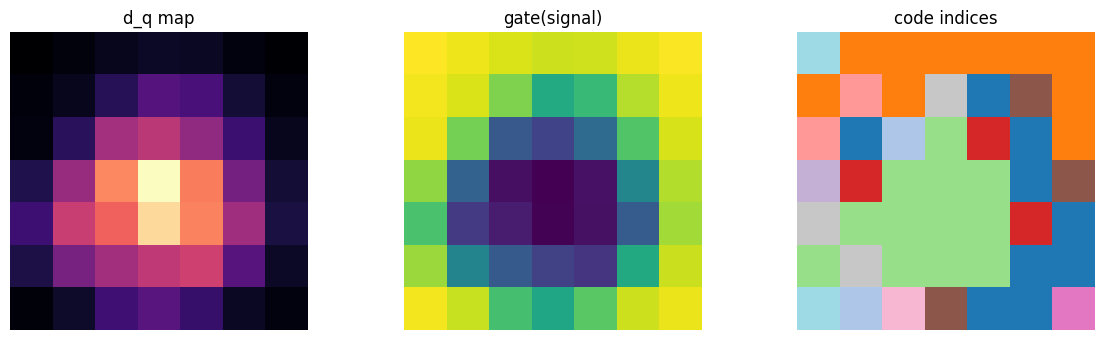

Debug: {'perplexity': 13.172664642333984, 'dq_mean': 0.26475682854652405, 'signal_mean': 0.5462194085121155, 'tau': 0.0384623184800148, 'alpha_softplus': 1.687295913696289, 'memory_scale': 1.0386244058609009}


In [25]:
def evaluate_clean_noisy(model, loader, config: Config, noise_std: float = 0.5, max_batches: int = 20):
    model.eval()
    clean_correct = 0
    noisy_correct = 0
    total = 0

    with torch.no_grad():
        for bi, (x, y) in enumerate(loader):
            if bi >= max_batches:
                break
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits_clean, _, _ = model(x, feature_noise_std=0.0)
            logits_noisy, _, _ = model(x, feature_noise_std=noise_std)

            clean_correct += (logits_clean.argmax(1) == y).sum().item()
            noisy_correct += (logits_noisy.argmax(1) == y).sum().item()
            total += y.size(0)

    return {
        'clean_acc': clean_correct / max(1, total),
        'noisy_acc': noisy_correct / max(1, total),
    }

metrics = evaluate_clean_noisy(model, testloader, cfg, noise_std=cfg.feature_noise_std, max_batches=10)
print('Test metrics:', metrics)

# inspección visual de un sample
model.eval()
with torch.no_grad():
    x, y = next(iter(testloader))
    x = x[:1].to(device)
    _, _, _, dbg = model(x, feature_noise_std=cfg.feature_noise_std, return_debug=True)

    dq = dbg['dq_map'][0, 0].detach().cpu().numpy()
    gate = dbg['signal'][0, 0].detach().cpu().numpy()
    code = dbg['code_map'][0].detach().cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
ax[0].imshow(dq, cmap='magma'); ax[0].set_title('d_q map'); ax[0].axis('off')
ax[1].imshow(gate, cmap='viridis'); ax[1].set_title('gate(signal)'); ax[1].axis('off')
ax[2].imshow(code, cmap='tab20'); ax[2].set_title('code indices'); ax[2].axis('off')
plt.tight_layout()
plt.show()

print('Debug:', {
    'perplexity': float(dbg['perplexity'].item()),
    'dq_mean': float(dbg['dq_map'].mean().item()),
    'signal_mean': float(dbg['signal'].mean().item()),
    'tau': float(model.gate_tau.item()),
    'alpha_softplus': float(F.softplus(model.gate_alpha).item()),
    'memory_scale': float(model.memory_scale.item()),
})